In [1]:
import pennylane as qml
from pennylane import numpy as np
from os import listdir
import time 
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import random
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
from transformers import pipeline
from surrogate import SurrogateLSTM,SurrogateGRU
from Qnn import QLSTM,QGRU
device= torch.device("cpu")

### Dataset and Preprocessing

In [2]:
import random
import numpy as np

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
dataset=pd.read_csv("sarcasm_train.csv",delimiter=",")
dataset

,Unnamed: 0,headline,is_sarcastic
0,0,when the core is shaky,0
1,1,lessons from kodak,0
2,2,dancing with thieves,0
3,3,5 spectacular april getaways,0
4,4,produce manager ready for some football,1
...,...,...,...
995,995,suri cruise somehow already 11,1
996,996,worst person woman knows pregnant,1
997,997,the mediterranean refugee crisis,0
998,998,drunk driver in the zone,1


In [4]:
tokenizer = BertTokenizer.from_pretrained('google-bert/bert-base-uncased')

pipe = pipeline( model="google-bert/bert-base-uncased")

Some weights of the model checkpoint at google-bert/bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0


In [5]:
model_class, tokenizer_class, pretrained_weights = (BertModel, BertTokenizer, 'google-bert/bert-base-uncased')

# Load pretrained model/tokenizer
tokenizer = tokenizer_class.from_pretrained(pretrained_weights)
model = model_class.from_pretrained(pretrained_weights)

In [6]:
tokenzition=dataset['headline'].apply((lambda x: tokenizer.encode(x, add_special_tokens=True)))
tokenzition

0            [101, 2043, 1996, 4563, 2003, 15311, 102]
1                 [101, 8220, 2013, 12849, 23597, 102]
2                        [101, 5613, 2007, 15862, 102]
3      [101, 1019, 12656, 2258, 2131, 9497, 2015, 102]
4       [101, 3965, 3208, 3201, 2005, 2070, 2374, 102]
                            ...                       
995     [101, 7505, 2072, 8592, 5064, 2525, 2340, 102]
996           [101, 5409, 2711, 2450, 4282, 6875, 102]
997                [101, 1996, 7095, 13141, 5325, 102]
998           [101, 7144, 4062, 1999, 1996, 4224, 102]
999         [101, 23957, 2805, 15212, 1039, 9057, 102]
Name: headline, Length: 1000, dtype: object

In [7]:
all_tokens = []
for sentence in dataset['headline']:
    tokens = tokenizer.tokenize(sentence)
    all_tokens.extend(tokens)


In [8]:
unique_tokens = set(all_tokens)
vocab_size = len(unique_tokens)
print(vocab_size)

2607


In [9]:
def max_length(sentence:list)->int:
  max:int=0
  for sent in sentence:
    if max<len(sent):
       max=len(sent)
  return max
max_sentence=max_length(tokenzition)
print(max_sentence)

8


In [10]:
padded=np.array([i + [0]*(max_sentence-len(i)) for i in tokenzition.values])

In [11]:
attention_mask = np.where(padded == 0,0,1)
attention_mask.shape

(1000, 8)

In [12]:
#convert the input paddin into tensor
#def process_batch(batch_sentences):
token_ids= torch.tensor(padded)
  #convert the input mask into tensor
attention_mask = torch.tensor(attention_mask)
  # train the model
with torch.no_grad():
      last_hidden_states = model(token_ids, attention_mask=attention_mask)
#return last_hidden_states

In [13]:
word_embeddings = last_hidden_states[0].numpy()
word_embeddings.shape

(1000, 8, 768)

In [14]:
labels = dataset['is_sarcastic'].values

In [15]:
X_train, X_test, Y_train, Y_test = train_test_split(word_embeddings, labels, test_size = 0.3, random_state = 42)

In [16]:
# Scale the data
minmax = MinMaxScaler()

# Reshape X_train and X_test to 2D
X_train_2D = X_train.reshape(X_train.shape[0], -1)  # Reshape to (num_samples, num_features)
X_test_2D = X_test.reshape(X_test.shape[0], -1)  # Reshape to (num_samples, num_features)

# Apply MinMaxScaler to the reshaped data
X_train_scaled = minmax.fit_transform(X_train_2D)
X_test_scaled = minmax.transform(X_test_2D)

# Reshape the scaled data back to the original shape
X_train = X_train_scaled.reshape(X_train.shape)
X_test = X_test_scaled.reshape(X_test.shape)

X_test = np.clip(X_test, 0, 1)

In [17]:
X_train.shape

(700, 8, 768)

### Initialize the models for training

In [18]:
class ClassicalRNN(nn.Module):

    def __init__(self, embedding_dim, hidden_dim):
        super(ClassicalRNN, self).__init__()

        self.input_layer = nn.Linear(768, 384)
        self.projection = nn.Linear(384, 20)

        self.hidden_dim = hidden_dim

        self.model = nn.RNN(
            embedding_dim,
            hidden_dim
        )

        self.output = nn.Linear(hidden_dim, 1)

    def forward(self, sentence):

        sentence = self.input_layer(sentence)

        sentence = self.projection(sentence)

        # [batch, seq_len, 10]
        sentence = sentence.transpose(0, 1)

        # [seq_len, batch, 10]
        output, hidden = self.model(sentence)

        if isinstance(hidden, tuple):
            h_n, c_n = hidden
            last_hidden = h_n[-1]
        else:
            last_hidden = hidden[-1]

        # [batch, hidden]
        tag_logits = self.output(last_hidden)

        # Return logits because training uses BCEWithLogitsLoss
        return tag_logits

In [19]:
class ClassicalLSTM(nn.Module):

    def __init__(self, embedding_dim, hidden_dim):
        super(ClassicalLSTM, self).__init__()

        self.input_layer = nn.Linear(768, 384)
        self.projection = nn.Linear(384, 20)

        self.hidden_dim = hidden_dim

        self.model = nn.LSTM(
            embedding_dim,
            hidden_dim
        )

        self.output = nn.Linear(hidden_dim, 1)

    def forward(self, sentence):

        sentence = self.input_layer(sentence)

        sentence = self.projection(sentence)

        # [batch, seq_len, 10]
        sentence = sentence.transpose(0, 1)

        # [seq_len, batch, 10]
        output, hidden = self.model(sentence)

        if isinstance(hidden, tuple):
            h_n, c_n = hidden
            last_hidden = h_n[-1]
        else:
            last_hidden = hidden[-1]

        # [batch, hidden]
        tag_logits = self.output(last_hidden)

        # Return logits because training uses BCEWithLogitsLoss
        return tag_logits

In [20]:
class QuantumLSTM(nn.Module):

    def __init__(self, input_dim, hidden_dim, n_qubits=4,n_qlayers=1,entanglement=True):
        super(QuantumLSTM, self).__init__()
        
        self.input_layer = nn.Linear(768, 384)
        self.projection = nn.Linear(384, 20)

        self.hidden_dim = hidden_dim
        
       
        self.qlstm = QLSTM(
                        embedding_dim,
                        hidden_dim,
                        n_qubits=n_qubits,
                        n_qlayers=n_qlayers,
                        entanglement=entanglement
                    )
            
        self.output = nn.Linear(hidden_dim, 1)

    def forward(self, sentence):

        sentence = self.input_layer(sentence)

        sentence = self.projection(sentence)

        lstm_out, (h_n, c_n) = self.qlstm(sentence)

        last_hidden = h_n 

        # Regression output (next value prediction)
        out = self.output(last_hidden)

        return out

In [21]:
class ClassicalSLSTM(nn.Module):

    def __init__(self, input_dim, hidden_dim, n_qubits=4,n_qlayers=1,entanglement=True):
        super(ClassicalSLSTM, self).__init__()
        
        self.input_layer = nn.Linear(768, 384)
        self.projection = nn.Linear(384, 20)

        self.hidden_dim = hidden_dim
        
       
        self.qlstm = SurrogateLSTM(
                        embedding_dim,
                        hidden_dim,
                        n_qubits=n_qubits,
                    )
            
        self.output = nn.Linear(hidden_dim, 1)

    def forward(self, sentence):

        sentence = self.input_layer(sentence)

        sentence = self.projection(sentence)

        lstm_out, (h_n, c_n) = self.qlstm(sentence)

        last_hidden = h_n 

        # Regression output (next value prediction)
        out = self.output(last_hidden)

        return out

In [22]:
class ClassicalGRU(nn.Module):

    def __init__(self, embedding_dim, hidden_dim):
        super(ClassicalGRU, self).__init__()

        self.hidden_dim = hidden_dim

        # 768-dimensional BERT embedding -> 10-dimensional representation
        self.input_layer = nn.Linear(768, 384)
        self.projection = nn.Linear(384, 20)
        
        self.model = nn.GRU(
            embedding_dim,
            hidden_dim
        )

        self.output = nn.Linear(hidden_dim, 1)

    def forward(self, sentence):

        sentence = self.input_layer(sentence)

        sentence = self.projection(sentence)

        # [batch, seq_len, 10]
        sentence = sentence.transpose(0, 1)

        # [seq_len, batch, 10]
        output, hidden = self.model(sentence)

        # Classical PyTorch LSTM returns:
        # output = [seq_len, batch, hidden]
        # hidden = (h_n, c_n)

        if isinstance(hidden, tuple):
            h_n, c_n = hidden
            last_hidden = h_n[-1]
        else:
            last_hidden = hidden[-1]

        # [batch, hidden]
        tag_logits = self.output(last_hidden)

        # Return logits because training uses BCEWithLogitsLoss
        return tag_logits

In [23]:
class ClassicalSGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_qubits=4,n_qlayers=1,entanglement=True):
            super(ClassicalSGRU, self).__init__()

            self.input_layer = nn.Linear(768, 384)
            self.projection = nn.Linear(384, 20)
            

            self.hidden_dim = hidden_dim
            
        
            self.gru = SurrogateGRU(
                            embedding_dim,
                            hidden_dim,
                            n_qubits=n_qubits,
                        )
                
            self.output = nn.Linear(hidden_dim, 1)

    def forward(self, sentence):

        sentence = self.input_layer(sentence)

        sentence = self.projection(sentence)

        lstm_out, h_n = self.gru(sentence)

        last_hidden = h_n 

        # Regression output (next value prediction)
        out = self.output(last_hidden)

        return out


In [24]:
class QuantumGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_qubits=4,n_qlayers=1,entanglement=True):
            super(QuantumGRU, self).__init__()

            self.input_layer = nn.Linear(768, 384)
            self.projection = nn.Linear(384, 20)
            

            self.hidden_dim = hidden_dim
            
        
            self.gru = QGRU(
                            embedding_dim,
                            hidden_dim,
                            n_qubits=n_qubits,
                            n_qlayers=n_qlayers,
                            entanglement=entanglement
                        )
                
            self.output = nn.Linear(hidden_dim, 1)

    def forward(self, sentence):

        sentence = self.input_layer(sentence)

        sentence = self.projection(sentence)

        lstm_out, h_n = self.gru(sentence)

        last_hidden = h_n 

        # Regression output (next value prediction)
        out = self.output(last_hidden)

        return out


In [25]:
embedding_dim = 20
hidden_dim = 30
n_epochs = 51
num_qubits=5

### Classical Models parameters

In [26]:
rnn_model = ClassicalRNN(embedding_dim, hidden_dim)

In [27]:
lstm_model = ClassicalLSTM(embedding_dim, hidden_dim)

In [28]:
qlstm_model = QuantumLSTM(embedding_dim,hidden_dim,n_qubits=num_qubits)

In [29]:
gru_model = ClassicalGRU(embedding_dim,hidden_dim)

In [30]:
qgru_model = QuantumGRU(embedding_dim,hidden_dim,n_qubits=num_qubits)

In [31]:
slstm_model = ClassicalSLSTM(embedding_dim,hidden_dim,n_qubits=num_qubits)
sgru_model = ClassicalSGRU(embedding_dim,hidden_dim,n_qubits=num_qubits)

In [32]:
import torch
import torch.nn as nn

model = rnn_model
total_params = sum(p.numel() for p in model.parameters())
# Count trainable parameters only
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")


Total parameters: 304587
Trainable parameters: 304587


In [33]:
import torch
import torch.nn as nn

model = gru_model
total_params = sum(p.numel() for p in model.parameters())
# Count trainable parameters only
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

Total parameters: 307707
Trainable parameters: 307707


In [34]:
import torch
import torch.nn as nn

model = sgru_model
total_params = sum(p.numel() for p in model.parameters())
# Count trainable parameters only
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

Total parameters: 303492
Trainable parameters: 303492


In [35]:
import torch
import torch.nn as nn

model = qgru_model
total_params = sum(p.numel() for p in model.parameters())
# Count trainable parameters only
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

Total parameters: 303507
Trainable parameters: 303507


In [36]:
import torch
import torch.nn as nn

model = lstm_model
total_params = sum(p.numel() for p in model.parameters())
# Count trainable parameters only
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

Total parameters: 309267
Trainable parameters: 309267


In [37]:
import torch
import torch.nn as nn

model = qlstm_model
total_params = sum(p.numel() for p in model.parameters())
# Count trainable parameters only
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

Total parameters: 303522
Trainable parameters: 303522


In [38]:
import torch
import torch.nn as nn

model = slstm_model
total_params = sum(p.numel() for p in model.parameters())
# Count trainable parameters only
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

Total parameters: 303502
Trainable parameters: 303502


In [39]:
def accuracy_test(predictions, labels):
    predictions=predictions.cpu().detach().numpy()
    labels=labels.cpu().detach().numpy()
    return accuracy_score(predictions.round(), labels)


In [40]:
X_test.shape

(300, 8, 768)

### training the models

In [41]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim


def train(model, n_epochs, X_train, Y_train, X_test, Y_test):

    loss_function = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4,weight_decay=1e-4)

    history = {
        "loss": [],
        "accuracy": [],
        "test_loss": [],
        "test_accuracy": []
    }

    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)

    data_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=100,
        shuffle=True
    )
    start_time = time.perf_counter()

    for epoch in range(n_epochs):

        model.train()

        losses = []
        preds = []
        all_labels = []

        for xs, ys in data_loader:

            optimizer.zero_grad()

            # Forward pass
            logits = model(xs)

            # Convert [batch,1] -> [batch]
            logits = logits.squeeze()

            loss = loss_function(logits, ys)

            loss.backward()
            optimizer.step()

            losses.append(loss.item())

            probabilities = torch.sigmoid(logits)
            preds.append(probabilities.detach())
            all_labels.append(ys.detach())

        avg_loss = np.mean(losses)

        preds = torch.cat(preds)
        all_labels = torch.cat(all_labels)

        accuracy = accuracy_test(preds, all_labels)

        history["loss"].append(avg_loss)
        history["accuracy"].append(accuracy)

        # ------------------------
        # Validation
        # ------------------------
        model.eval()

        with torch.no_grad():

            test_logits = model(X_test).squeeze()

            test_loss = loss_function(test_logits, y_test)

            test_probs = torch.sigmoid(test_logits)

            test_accuracy = accuracy_test(
                test_probs,
                y_test
            )

        history["test_loss"].append(test_loss.item())
        history["test_accuracy"].append(test_accuracy)

        # if epoch % 5 == 0:
        #     print(
        #         f"Epoch {epoch}/{n_epochs} | "
        #         f"Loss={avg_loss:.4f} | "
        #         f"Acc={accuracy:.4f} | "
        #         f"Test Loss={test_loss.item():.4f} | "
        #         f"Test Acc={test_accuracy:.4f}"
            # )
    total_time = time.perf_counter() - start_time

    history["training_time"] = total_time

    return history

In [42]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(Y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(Y_test, dtype=torch.float32)

In [43]:
# train classical models

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    matthews_corrcoef,
    cohen_kappa_score
)

def evaluate_model(model, X_test, Y_test):

    model.eval()


    with torch.no_grad():

        test_logits = model(X_test).squeeze()
        test_probs = torch.sigmoid(test_logits)
        test_pred = test_probs.cpu().numpy().round()
        
    # print(classification_report(Y_test, test_pred))

    return {
        "accuracy": accuracy_score(Y_test, test_pred),
        "f1": f1_score(Y_test, test_pred, average="macro"),
        "precision": precision_score(Y_test, test_pred, average="macro"),
        "recall": recall_score(Y_test, test_pred, average="macro"),
        "mcc": matthews_corrcoef(Y_test, test_pred),
        "kappa": cohen_kappa_score(Y_test, test_pred),
        "y_pred": test_pred,
        "y_true": Y_test
    }

In [44]:
def run_models(model_name:str,seed:int,n_qlayers:int=1, entanglement:bool=True,n_qubits:int=5):

    set_seed(seed)

    if model_name == "slstm":
        model = ClassicalSLSTM(embedding_dim, hidden_dim)

    elif model_name == "sgru":
        model = ClassicalSGRU(embedding_dim, hidden_dim)

    elif model_name == "rnn":
        model = ClassicalRNN(embedding_dim, hidden_dim)

    elif model_name == "lstm":
        model = ClassicalLSTM(embedding_dim, hidden_dim)

    elif model_name == "gru":
        model = ClassicalGRU(embedding_dim, hidden_dim)   

    elif model_name=="qlstm":
        model = QuantumLSTM(embedding_dim, hidden_dim, n_qlayers=n_qlayers, entanglement=entanglement, n_qubits=n_qubits)

    elif model_name=="qgru":
        model = QuantumGRU(embedding_dim, hidden_dim, n_qlayers=n_qlayers, entanglement=entanglement, n_qubits=n_qubits)
        
    history = train(
        model,
        n_epochs,
        X_train,
        Y_train,
        X_test,
        Y_test
    )

    metrics = evaluate_model(model, X_test, Y_test)

    return {
        "model": model_name,
        "seed": seed,
        "n_qubits": n_qubits if model_name in ["qlstm", "qgru"] else None,
        "n_qlayers": n_qlayers if model_name in ["qlstm", "qgru"] else None,
        "entanglement": entanglement if model_name in ["qlstm", "qgru"] else None,
        "history": history,
        "train_time" : history["training_time"],
        "metrics": metrics
    }   

In [46]:
SEEDS = [42, 123, 456, 789, 999]

results = []
#classical models

for model_name in ["rnn","slstm", "sgru", "lstm", "gru"]:

    for seed in SEEDS:

        print(f"\nTraining {model_name.upper()} | Seed: {seed}")

        result = run_models(model_name, seed)

        results.append(result)


Training RNN | Seed: 42

Training RNN | Seed: 123

Training RNN | Seed: 456

Training RNN | Seed: 789

Training RNN | Seed: 999

Training SLSTM | Seed: 42

Training SLSTM | Seed: 123

Training SLSTM | Seed: 456

Training SLSTM | Seed: 789

Training SLSTM | Seed: 999

Training SGRU | Seed: 42

Training SGRU | Seed: 123

Training SGRU | Seed: 456

Training SGRU | Seed: 789

Training SGRU | Seed: 999

Training LSTM | Seed: 42

Training LSTM | Seed: 123

Training LSTM | Seed: 456

Training LSTM | Seed: 789

Training LSTM | Seed: 999

Training GRU | Seed: 42

Training GRU | Seed: 123

Training GRU | Seed: 456

Training GRU | Seed: 789

Training GRU | Seed: 999


In [ ]:
EXPERIMENTS = [
    {"n_qlayers": 1, "entanglement": False},
    {"n_qlayers": 1, "entanglement": True},

    {"n_qlayers": 2, "entanglement": False},
    {"n_qlayers": 2, "entanglement": True},
]

SEEDS = [42, 123, 456, 789, 999]

In [55]:
SEEDS = [42, 123, 456, 789, 999]


for exp in EXPERIMENTS:

    for seed in SEEDS:

        print(f"\nTraining QLSTM | Seed: {seed}")

        result = run_models("qlstm", seed,n_qubits=3,n_qlayers=exp["n_qlayers"],entanglement=exp["entanglement"])

        results.append(result)


Training QLSTM | Seed: 42

Training QLSTM | Seed: 123

Training QLSTM | Seed: 456

Training QLSTM | Seed: 789

Training QLSTM | Seed: 999

Training QLSTM | Seed: 42

Training QLSTM | Seed: 123

Training QLSTM | Seed: 456

Training QLSTM | Seed: 789

Training QLSTM | Seed: 999

Training QLSTM | Seed: 42

Training QLSTM | Seed: 123

Training QLSTM | Seed: 456

Training QLSTM | Seed: 789

Training QLSTM | Seed: 999

Training QLSTM | Seed: 42

Training QLSTM | Seed: 123

Training QLSTM | Seed: 456

Training QLSTM | Seed: 789

Training QLSTM | Seed: 999


In [112]:
SEEDS = [42, 123, 456, 789, 999]


for exp in EXPERIMENTS:

    for seed in SEEDS:

        print(f"\nTraining QGRU | Seed: {seed}")

        result = run_models("qgru", seed,n_qubits=4,n_qlayers=exp["n_qlayers"],entanglement=exp["entanglement"])

        results.append(result)


Training QGRU | Seed: 42

Training QGRU | Seed: 123

Training QGRU | Seed: 456

Training QGRU | Seed: 789

Training QGRU | Seed: 999


## Evaluation

In [ ]:
import numpy as np
from statsmodels.stats.contingency_tables import mcnemar


# 1. Select one experimental configuration
def get_results(results, model, n_qubits=None, n_qlayers=None,
                entanglement=None):
    
    selected = []

    for r in results:

        if r["model"] != model:
            continue

        if model in ["qgru", "qlstm"]:

            if r["n_qubits"] != n_qubits:
                continue

            if r["n_qlayers"] != n_qlayers:
                continue

            if r["entanglement"] != entanglement:
                continue

        selected.append(r)

    return selected


# 2. McNemar test for two results from the same seed
def run_mcnemar(result_a, result_b):

    y_true_a = np.asarray(result_a["metrics"]["y_true"])
    y_pred_a = np.asarray(result_a["metrics"]["y_pred"]).astype(int)

    y_true_b = np.asarray(result_b["metrics"]["y_true"])
    y_pred_b = np.asarray(result_b["metrics"]["y_pred"]).astype(int)

    # Make sure both models use the same test set
    if not np.array_equal(y_true_a, y_true_b):
        raise ValueError("Models do not use the same test labels.")

    # Correct / incorrect predictions
    correct_a = y_pred_a == y_true_a
    correct_b = y_pred_b == y_true_b

    # McNemar contingency table
    table = np.array([
        [
            np.sum(correct_a & correct_b),
            np.sum(correct_a & ~correct_b)
        ],
        [
            np.sum(~correct_a & correct_b),
            np.sum(~correct_a & ~correct_b)
        ]
    ])

    test = mcnemar(table, exact=True)

    return {
        "table": table,
        "statistic": test.statistic,
        "p_value": test.pvalue
    }


# 3. Run McNemar for matching seeds
def compare_models_mcnemar(results, results_a, results_b):

    results_a = {r["seed"]: r for r in results_a}
    results_b = {r["seed"]: r for r in results_b}

    common_seeds = sorted(
        set(results_a.keys()) & set(results_b.keys())
    )

    output = []

    for seed in common_seeds:

        result = run_mcnemar(
            results_a[seed],
            results_b[seed]
        )

        output.append({
            "seed": seed,
            "statistic": result["statistic"],
            "p_value": result["p_value"],
            "table": result["table"]
        })

    return output

In [128]:
# ============================================================
# QGRU (4 qubits, 1 layer, no CNOT)
# vs
# GRU
# ============================================================

qgru_best = get_results(
    results,
    model="qgru",
    n_qubits=4,
    n_qlayers=1,
    entanglement=False
)

gru_results = get_results(
    results,
    model="gru"
)

qgru_vs_gru = compare_models_mcnemar(
    results,
    qgru_best,
    gru_results
)

for r in qgru_vs_gru:

    print(f"\nSeed: {r['seed']}")
    print("Contingency table:")
    print(r["table"])
    print(f"McNemar statistic: {r['statistic']}")
    print(f"p-value: {r['p_value']:.4f}")


Seed: 42
Contingency table:
[[263   3]
 [  4  30]]
McNemar statistic: 3.0
p-value: 1.0000

Seed: 123
Contingency table:
[[250  13]
 [  9  28]]
McNemar statistic: 9.0
p-value: 0.5235

Seed: 456
Contingency table:
[[259   8]
 [  3  30]]
McNemar statistic: 3.0
p-value: 0.2266

Seed: 789
Contingency table:
[[260   4]
 [  3  33]]
McNemar statistic: 3.0
p-value: 1.0000

Seed: 999
Contingency table:
[[260   2]
 [  6  32]]
McNemar statistic: 2.0
p-value: 0.2891


In [129]:
qlstm_best = get_results(
    results,
    model="qlstm",
    n_qubits=5,
    n_qlayers=2,
    entanglement=False
)

lstm_results = get_results(
    results,
    model="lstm"
)

qlstm_vs_lstm = compare_models_mcnemar(
    results,
    qlstm_best,
    lstm_results
)

for r in qlstm_vs_lstm:

    print(f"\nSeed: {r['seed']}")
    print("Contingency table:")
    print(r["table"])
    print(f"McNemar statistic: {r['statistic']}")
    print(f"p-value: {r['p_value']:.4f}")


Seed: 42
Contingency table:
[[256   2]
 [  4  38]]
McNemar statistic: 2.0
p-value: 0.6875

Seed: 123
Contingency table:
[[260   7]
 [  6  27]]
McNemar statistic: 6.0
p-value: 1.0000

Seed: 456
Contingency table:
[[259   7]
 [  3  31]]
McNemar statistic: 3.0
p-value: 0.3438

Seed: 789
Contingency table:
[[250  17]
 [ 11  22]]
McNemar statistic: 11.0
p-value: 0.3449

Seed: 999
Contingency table:
[[262   1]
 [  7  30]]
McNemar statistic: 1.0
p-value: 0.0703


In [113]:
import pandas as pd

rows = []

for result in results:

    row = {
        "model": result["model"],
        "seed": result["seed"],
        "n_qubits": result.get("n_qubits", None),
        "entanglement": result.get("entanglement", None),
        "n_qlayers": result.get("n_qlayers", None),
        "train_time": result["train_time"]
    }

    row.update(result["metrics"])

    rows.append(row)

results_df = pd.DataFrame(rows)

results_df

,model,seed,n_qubits,entanglement,n_qlayers,train_time,accuracy,f1,precision,recall,mcc,kappa,y_pred,y_true
0,lstm,42,NaN,None,NaN,8.825942,0.790000,0.787428,0.816602,0.795673,0.611918,0.584323,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, ...","[0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, ..."
1,lstm,123,NaN,None,NaN,5.818468,0.883333,0.882381,0.888141,0.881143,0.769252,0.765353,"[0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, ...","[0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, ..."
2,lstm,456,NaN,None,NaN,5.973561,0.850000,0.849985,0.852469,0.851763,0.704231,0.700718,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, ...","[0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, ..."
3,lstm,789,NaN,None,NaN,5.579848,0.883333,0.881904,0.892449,0.880342,0.772696,0.764974,"[0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, ...","[0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, ..."
4,lstm,999,NaN,None,NaN,5.458187,0.876667,0.874965,0.887275,0.873397,0.760546,0.751411,"[0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, ...","[0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,qgru,42,4.0,False,1.0,229.946287,0.886667,0.886419,0.886700,0.886218,0.772918,0.772849,"[0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, ...","[0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, ..."
125,qgru,123,4.0,False,1.0,227.489759,0.876667,0.876556,0.876417,0.876870,0.753287,0.753136,"[0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, ...","[0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, ..."
126,qgru,456,4.0,False,1.0,226.167154,0.890000,0.889557,0.891205,0.888889,0.780091,0.779235,"[0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, ...","[0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, ..."
127,qgru,789,4.0,False,1.0,228.338374,0.880000,0.879867,0.879737,0.880075,0.759811,0.759744,"[0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, ...","[0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, ..."


In [114]:
results_df["n_qlayers"] = (
    results_df["n_qlayers"]
    .fillna("N/A")
)

results_df["entanglement"] = (
    results_df["entanglement"]
    .fillna("N/A")
)

results_df["n_qubits"] = (
    results_df["n_qubits"]
    .fillna("N/A")
)


In [115]:
summary_df = (
    results_df
    .groupby(
        ["model", "n_qubits", "n_qlayers", "entanglement"]
    )
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),

        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),

        precision_mean=("precision", "mean"),
        precision_std=("precision", "std"),

        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),

        train_time_mean=("train_time", "mean"),
        train_time_std=("train_time", "std")
    )
    .reset_index()
)

summary_df

,model,n_qubits,n_qlayers,entanglement,accuracy_mean,accuracy_std,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std,train_time_mean,train_time_std
0,gru,N/A,N/A,N/A,0.876444,0.012049,0.875763,0.012649,0.879673,0.010387,0.875481,0.012735,6.067686,0.496540
1,lstm,N/A,N/A,N/A,0.871333,0.025629,0.870781,0.026041,0.875085,0.020730,0.871314,0.023841,5.805701,1.183265
2,qgru,3.0,1.0,False,0.816000,0.045324,0.811858,0.049955,0.838296,0.027817,0.816720,0.046659,180.895561,7.266788
3,qgru,3.0,1.0,True,0.825333,0.052207,0.821454,0.056345,0.846883,0.033818,0.825427,0.051956,185.558628,5.140857
4,qgru,3.0,2.0,False,0.860667,0.021782,0.859917,0.021295,0.868072,0.023159,0.860897,0.019260,232.374859,1.176502
5,qgru,3.0,2.0,True,0.854667,0.027749,0.853267,0.029021,0.864279,0.021520,0.854434,0.027941,259.113597,4.433923
6,qgru,4.0,1.0,False,0.881333,0.006912,0.881136,0.006766,0.881478,0.007363,0.881197,0.006268,227.566499,1.660633
7,qgru,5.0,1.0,False,0.870667,0.027528,0.869797,0.027695,0.877271,0.024283,0.870192,0.025901,286.849728,7.107007
8,qgru,5.0,1.0,True,0.842667,0.062290,0.840174,0.064925,0.857361,0.046215,0.842949,0.059846,319.150471,7.971644
9,qgru,5.0,2.0,False,0.857333,0.039889,0.856346,0.040023,0.866428,0.035332,0.857639,0.036610,412.567679,2.406379


In [ ]:
summary_df.to_csv("results.csv", index=False)

In [117]:
import pandas as pd

quantum_summary = (
    results_df
    .query("model in ['qlstm','qgru']")
    .groupby(
        ["model","n_qubits","n_qlayers","entanglement"]
    )["f1"]
    .mean()
    .reset_index()
)

best_qlstm = (
    quantum_summary
    .query("model=='qlstm'")
    .sort_values("f1", ascending=False)
    .iloc[0]
)

best_qgru = (
    quantum_summary
    .query("model=='qgru'")
    .sort_values("f1", ascending=False)
    .iloc[0]
)

print(best_qlstm)
print(best_qgru)

model              qlstm
n_qubits             5.0
n_qlayers            2.0
entanglement       False
f1              0.880159
Name: 15, dtype: object
model               qgru
n_qubits             4.0
n_qlayers            1.0
entanglement       False
f1              0.881136
Name: 4, dtype: object


In [118]:
import numpy as np
import matplotlib.pyplot as plt


def get_mean_history(results, model_name,
                     n_qubits=None,
                     n_qlayers=None,
                     entanglement=None):

    selected = []

    for r in results:

        if r["model"] != model_name:
            continue

        if model_name in ["qlstm","qgru"]:

            if r["n_qubits"] != n_qubits:
                continue

            if r["n_qlayers"] != n_qlayers:
                continue

            if r["entanglement"] != entanglement:
                continue

        selected.append(r)

    train_acc = np.array(
        [r["history"]["accuracy"] for r in selected]
    )

    test_acc = np.array(
        [r["history"]["test_accuracy"] for r in selected]
    )
    train_loss = np.array(
    [r["history"]["loss"] for r in selected]
    )

    test_loss = np.array(
        [r["history"]["test_loss"] for r in selected]
    )

    return {
    "train_acc_mean": train_acc.mean(axis=0),
    "test_acc_mean": test_acc.mean(axis=0),

    "train_loss_mean": train_loss.mean(axis=0),
    "test_loss_mean": test_loss.mean(axis=0),
    }   

In [119]:
def plot_lstm_vs_best_qlstm(results, best_qlstm):

    lstm_hist = get_mean_history(
        results,
        "lstm"
    )

    qlstm_hist = get_mean_history(
        results,
        "qlstm",
        n_qubits=best_qlstm["n_qubits"],
        n_qlayers=best_qlstm["n_qlayers"],
        entanglement=best_qlstm["entanglement"]
    )

    epochs = np.arange(
        1,
        len(lstm_hist["train_acc_mean"]) + 1
    )

    plt.figure(figsize=(8, 5))

    # Train accuracy
    plt.plot(
        epochs,
        lstm_hist["train_acc_mean"],
        label="LSTM   (Train)"
    )


    # Test accuracy
    plt.plot(
        epochs,
        lstm_hist["test_acc_mean"],
        "--",
        label="LSTM   (Test)"
    )

    plt.plot(
            epochs,
            qlstm_hist["train_acc_mean"],
            label="QLSTM (Train)"
        )

    plt.plot(
        epochs,
        qlstm_hist["test_acc_mean"],
        "--",
        label="QLSTM (Test)"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Average Accuracy History")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [120]:
def plot_gru_vs_best_qgru(results, best_qgru):

    gru_hist = get_mean_history(
        results,
        "gru"
    )

    qgru_hist = get_mean_history(
        results,
        "qgru",
        n_qubits=best_qgru["n_qubits"],
        n_qlayers=best_qgru["n_qlayers"],
        entanglement=best_qgru["entanglement"]
    )

    epochs = np.arange(
        1,
        len(gru_hist["train_acc_mean"]) + 1
    )

    plt.figure(figsize=(8,5))

    plt.plot(
        epochs,
        gru_hist["train_acc_mean"],
        label="GRU   (Train)"
    )


    plt.plot(
        epochs,
        gru_hist["test_acc_mean"],
        "--",
        label="GRU   (Test)"
    )

    plt.plot(
            epochs,
            qgru_hist["train_acc_mean"],
            label="QGRU (Train)"
        )

    plt.plot(
        epochs,
        qgru_hist["test_acc_mean"],
        "--",
        label="QGRU (Test)"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Average Accuracy History")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

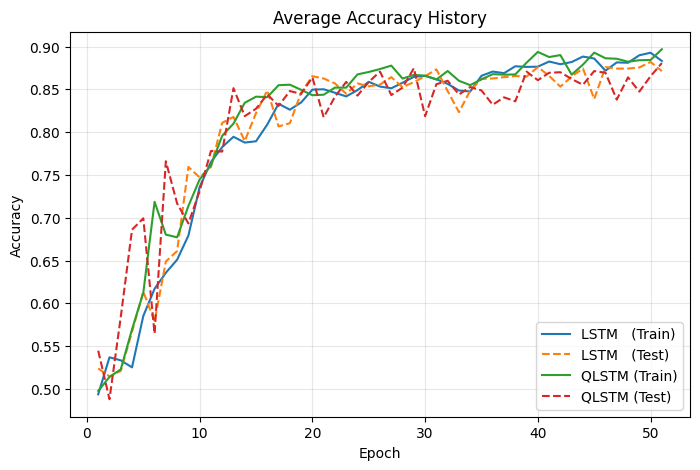

In [121]:
plot_lstm_vs_best_qlstm(results, best_qlstm)

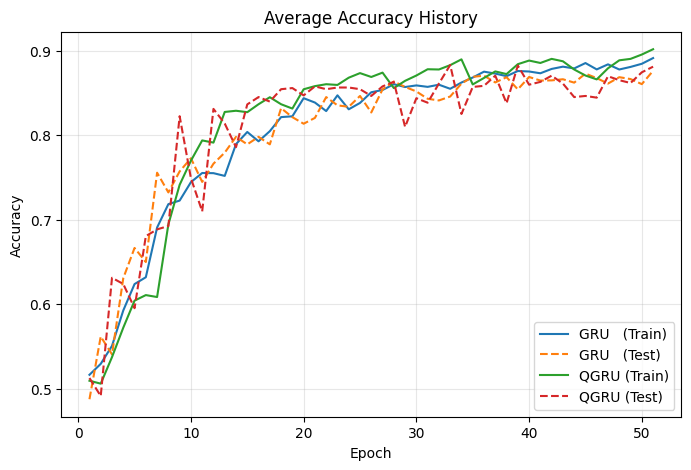

In [122]:
plot_gru_vs_best_qgru(results, best_qgru)

In [123]:
def plot_lstm_vs_best_qlstm_loss(results, best_qlstm):

    lstm_hist = get_mean_history(
        results,
        "lstm"
    )

    qlstm_hist = get_mean_history(
        results,
        "qlstm",
        n_qubits=best_qlstm["n_qubits"],
        n_qlayers=best_qlstm["n_qlayers"],
        entanglement=best_qlstm["entanglement"]
    )

    epochs = np.arange(
        1,
        len(lstm_hist["train_loss_mean"]) + 1
    )

    plt.figure(figsize=(8,5))

    plt.plot(
        epochs,
        lstm_hist["train_loss_mean"],
        label="LSTM (Train)"
    )

    

    plt.plot(
        epochs,
        lstm_hist["test_loss_mean"],
        "--",
        label="LSTM (Test)"
    )

    plt.plot(
            epochs,
            qlstm_hist["train_loss_mean"],
            label="QLSTM (Train)"
        )

    plt.plot(
        epochs,
        qlstm_hist["test_loss_mean"],
        "--",
        label="QLSTM (Test)"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Average Loss History")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [124]:
def plot_gru_vs_best_qgru_loss(results, best_qgru):

    gru_hist = get_mean_history(
        results,
        "gru"
    )

    qgru_hist = get_mean_history(
        results,
        "qgru",
        n_qubits=best_qgru["n_qubits"],
        n_qlayers=best_qgru["n_qlayers"],
        entanglement=best_qgru["entanglement"]
    )

    epochs = np.arange(
        1,
        len(gru_hist["train_loss_mean"]) + 1
    )

    plt.figure(figsize=(8,5))

    plt.plot(
        epochs,
        gru_hist["train_loss_mean"],
        label="GRU (Train)"
    )

    

    plt.plot(
        epochs,
        gru_hist["test_loss_mean"],
        "--",
        label="GRU (Test)"
    )

    plt.plot(
            epochs,
            qgru_hist["train_loss_mean"],
            label="QGRU (Train)"
        )

    plt.plot(
        epochs,
        qgru_hist["test_loss_mean"],
        "--",
        label="QGRU (Test)"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Average Loss History")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

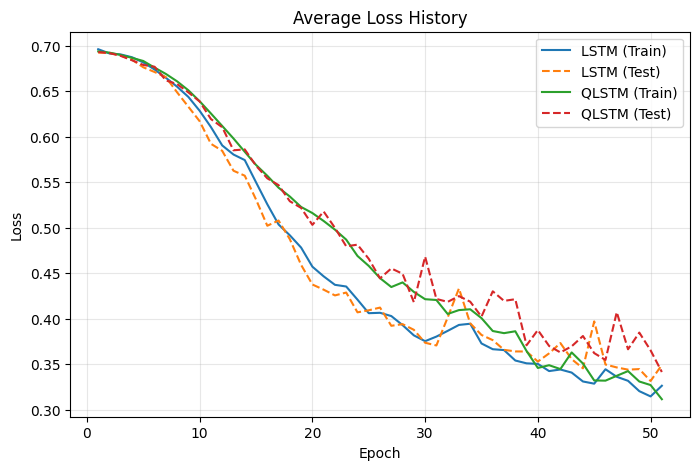

In [125]:
plot_lstm_vs_best_qlstm_loss(results, best_qlstm)

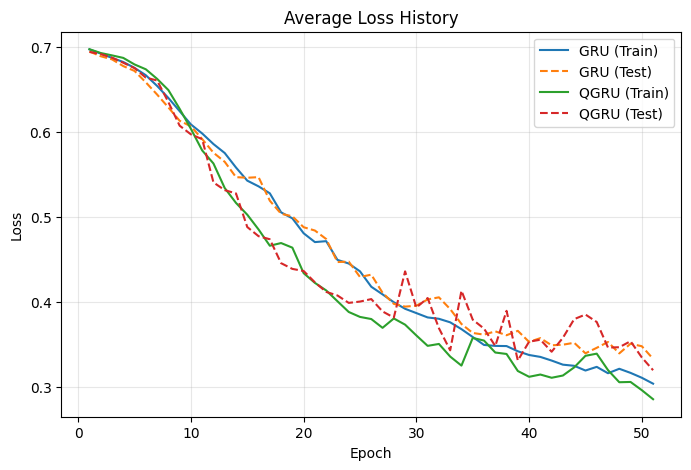

In [126]:
plot_gru_vs_best_qgru_loss(results, best_qgru)